In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'MobileNetV2'
MODEL_NAME

'MobileNetV2'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for DenseNet121 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class MobileNetV2(nn.Module):
    """
    MobileNetV2-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: MobileNetV2 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained MobileNetV2
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        backbone = models.mobilenet_v2(weights=weights)

        # MobileNetV2 .features contains all the convolutional layers (Inverted Residuals)
        self.features = backbone.features

        # Unfreeze ALL
        for param in self.features.parameters():
            param.requires_grad = True

        # Define Custom Classifier Head
        # MobileNetV2 output feature map has 1280 channels
        self.in_features = 1280 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1280, H, W) -> (Batch, 1280, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1280, 1, 1) -> (Batch, 1280)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_mobilenetv2(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> MobileNetV2:
    """
    Factory function to instantiate the customized MobileNetV2 model for Transfer Learning.

    This function initializes a `MobileNetV2` which includes:
    1. A frozen MobileNetV2 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        MobileNetV2: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = MobileNetV2(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the MobileNetV2 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_mobilenetv2().to(device=device)

    # Model Summary
    print(f"\nFold: {fold_k} - base")
    
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1
            ))
    
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_base_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        # Disable BatchNorm
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_base_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_mobilenetv2().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Base)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 Base
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 185MB/s]



Fold: 1 - base
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 3419.19
Params 

Epoch 1/50 | loss: 0.2225 - accuracy: 0.7613 | val_loss: 0.0875 - val_accuracy: 0.9373
val_accuracy improved from 0.0000 to 0.9373, saving weights to /kaggle/working/MobileNetV2_base_fold_1.pth


Epoch 2/50 | loss: 0.1055 - accuracy: 0.8807 | val_loss: 0.1312 - val_accuracy: 0.8192
val_accuracy did not improve from 0.9373


...

Epoch 20/50 | loss: 0.0024 - accuracy: 0.9976 | val_loss: 0.0176 - val_accuracy: 0.9815
val_accuracy did not improve from 0.9815


Epoch 21/50 | loss: 0.0035 - accuracy: 0.9964 | val_loss: 0.0176 - val_accuracy: 0.9815
val_accuracy did not improve from 0.9815


Epoch 22/50 | loss: 0.0027 - accuracy: 0.9972 | val_loss: 0.0180 - val_accuracy: 0.9815
val_accuracy did not improve from 0.9815


Epoch 23/50 | loss: 0.0024 - accuracy: 0.9976 | val_loss: 0.0178 - val_accuracy: 0.9815
val_accuracy did not improve from 0.9815


Epoch 24/50 | loss: 0.0027 - accuracy: 0.9956 | val_loss: 0.0176 - val_accuracy: 0.9815
val_accuracy did not improve from 0.9815
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.017241   0.98155
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       245
Meningioma Tumor       0.96      0.96      0.96       112
 Pituitary Tumor       0.99      0.99      0.99       185

        accuracy                           0.98       542
       macro avg       0.98      0.98      0.98       542
    weighted avg       0.98      0.98      0.98       542



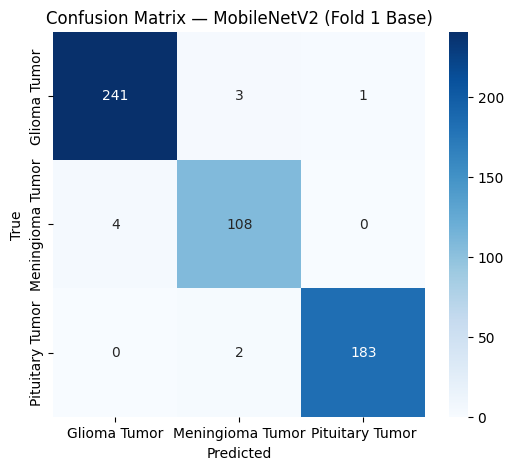

Fold: 2 Base

Fold: 2 - base
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 34

Epoch 1/50 | loss: 0.2601 - accuracy: 0.7254 | val_loss: 0.1308 - val_accuracy: 0.8689
val_accuracy improved from 0.0000 to 0.8689, saving weights to /kaggle/working/MobileNetV2_base_fold_2.pth


Epoch 2/50 | loss: 0.1249 - accuracy: 0.8683 | val_loss: 0.0941 - val_accuracy: 0.9013
val_accuracy improved from 0.8689 to 0.9013, saving weights to /kaggle/working/MobileNetV2_base_fold_2.pth


Epoch 3/50 | loss: 0.0799 - accuracy: 0.9199 | val_loss: 0.0686 - val_accuracy: 0.9146
val_accuracy improved from 0.9013 to 0.9146, saving weights to /kaggle/working/MobileNetV2_base_fold_2.pth


Epoch 4/50 | loss: 0.0473 - accuracy: 0.9505 | val_loss: 0.0942 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9146


...

Epoch 17/50 | loss: 0.0094 - accuracy: 0.9874 | val_loss: 0.0621 - val_accuracy: 0.9381
val_accuracy did not improve from 0.9529


Epoch 18/50 | loss: 0.0101 - accuracy: 0.9870 | val_loss: 0.0928 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9529


Epoch 19/50 | loss: 0.0076 - accuracy: 0.9916 | val_loss: 0.0504 - val_accuracy: 0.9485
val_accuracy did not improve from 0.9529


Epoch 20/50 | loss: 0.0043 - accuracy: 0.9954 | val_loss: 0.0493 - val_accuracy: 0.9529
val_accuracy did not improve from 0.9529


Epoch 21/50 | loss: 0.0043 - accuracy: 0.9950 | val_loss: 0.0512 - val_accuracy: 0.9514
val_accuracy did not improve from 0.9529
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.044229  0.952872
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.97      0.96       338
Meningioma Tumor       0.93      0.92      0.92       167
 Pituitary Tumor       0.98      0.96      0.97       174

        accuracy                           0.95       679
       macro avg       0.95      0.95      0.95       679
    weighted avg       0.95      0.95      0.95       679



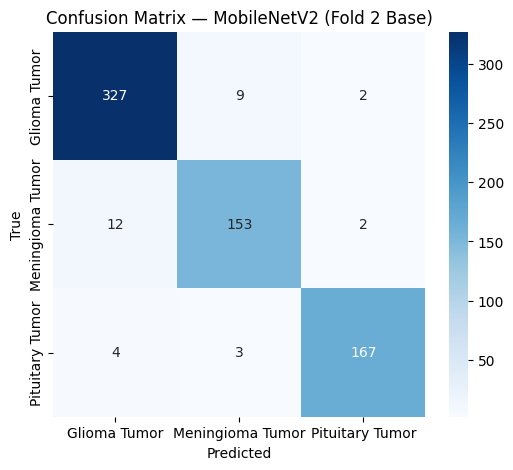

Fold: 3 Base

Fold: 3 - base
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 34

Epoch 1/50 | loss: 0.2197 - accuracy: 0.7648 | val_loss: 0.1158 - val_accuracy: 0.8864
val_accuracy improved from 0.0000 to 0.8864, saving weights to /kaggle/working/MobileNetV2_base_fold_3.pth


Epoch 2/50 | loss: 0.0975 - accuracy: 0.8820 | val_loss: 0.0961 - val_accuracy: 0.8829
val_accuracy did not improve from 0.8864


Epoch 3/50 | loss: 0.1043 - accuracy: 0.8933 | val_loss: 0.0693 - val_accuracy: 0.9301
val_accuracy improved from 0.8864 to 0.9301, saving weights to /kaggle/working/MobileNetV2_base_fold_3.pth


Epoch 4/50 | loss: 0.0590 - accuracy: 0.9326 | val_loss: 0.0570 - val_accuracy: 0.9441
val_accuracy improved from 0.9301 to 0.9441, saving weights to /kaggle/working/MobileNetV2_base_fold_3.pth


...

Epoch 14/50 | loss: 0.0221 - accuracy: 0.9779 | val_loss: 0.1489 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9633


Epoch 15/50 | loss: 0.0363 - accuracy: 0.9667 | val_loss: 0.0876 - val_accuracy: 0.9406
val_accuracy did not improve from 0.9633


Epoch 16/50 | loss: 0.0127 - accuracy: 0.9860 | val_loss: 0.1028 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9633


Epoch 17/50 | loss: 0.0092 - accuracy: 0.9928 | val_loss: 0.0608 - val_accuracy: 0.9545
val_accuracy did not improve from 0.9633


Epoch 18/50 | loss: 0.0038 - accuracy: 0.9964 | val_loss: 0.0680 - val_accuracy: 0.9476
val_accuracy did not improve from 0.9633
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.036493  0.963287
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.95      0.96       231
Meningioma Tumor       0.92      0.94      0.93       139
 Pituitary Tumor       0.99      1.00      0.99       202

        accuracy                           0.96       572
       macro avg       0.96      0.96      0.96       572
    weighted avg       0.96      0.96      0.96       572



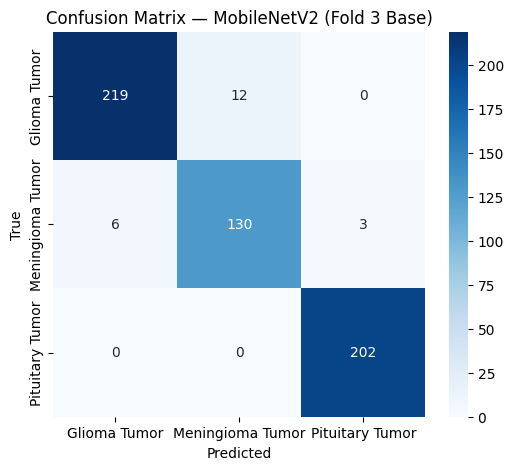

Fold: 4 Base

Fold: 4 - base
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 34

Epoch 1/50 | loss: 0.2295 - accuracy: 0.7586 | val_loss: 0.0991 - val_accuracy: 0.8997
val_accuracy improved from 0.0000 to 0.8997, saving weights to /kaggle/working/MobileNetV2_base_fold_4.pth


Epoch 2/50 | loss: 0.1122 - accuracy: 0.8666 | val_loss: 0.0869 - val_accuracy: 0.9204
val_accuracy improved from 0.8997 to 0.9204, saving weights to /kaggle/working/MobileNetV2_base_fold_4.pth


Epoch 3/50 | loss: 0.0816 - accuracy: 0.9039 | val_loss: 0.0992 - val_accuracy: 0.8742
val_accuracy did not improve from 0.9204


Epoch 4/50 | loss: 0.0718 - accuracy: 0.9117 | val_loss: 0.0515 - val_accuracy: 0.9475
val_accuracy improved from 0.9204 to 0.9475, saving weights to /kaggle/working/MobileNetV2_base_fold_4.pth


...

Epoch 28/50 | loss: 0.0012 - accuracy: 0.9984 | val_loss: 0.0494 - val_accuracy: 0.9697
val_accuracy did not improve from 0.9697


Epoch 29/50 | loss: 0.0017 - accuracy: 0.9979 | val_loss: 0.0494 - val_accuracy: 0.9682
val_accuracy did not improve from 0.9697


Epoch 30/50 | loss: 0.0008 - accuracy: 0.9992 | val_loss: 0.0494 - val_accuracy: 0.9682
val_accuracy did not improve from 0.9697


Epoch 31/50 | loss: 0.0024 - accuracy: 0.9967 | val_loss: 0.0493 - val_accuracy: 0.9682
val_accuracy did not improve from 0.9697


Epoch 32/50 | loss: 0.0016 - accuracy: 0.9979 | val_loss: 0.0490 - val_accuracy: 0.9697
val_accuracy did not improve from 0.9697
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.049923  0.969745
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.99      0.98       325
Meningioma Tumor       0.92      0.94      0.93       124
 Pituitary Tumor       0.99      0.96      0.98       179

        accuracy                           0.97       628
       macro avg       0.96      0.96      0.96       628
    weighted avg       0.97      0.97      0.97       628



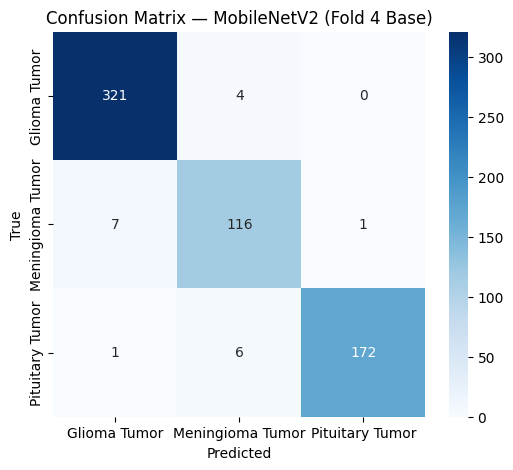

Fold: 5 Base

Fold: 5 - base
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 34

Epoch 1/50 | loss: 0.2236 - accuracy: 0.7695 | val_loss: 0.1648 - val_accuracy: 0.8320
val_accuracy improved from 0.0000 to 0.8320, saving weights to /kaggle/working/MobileNetV2_base_fold_5.pth


Epoch 2/50 | loss: 0.0896 - accuracy: 0.8971 | val_loss: 0.3758 - val_accuracy: 0.7481
val_accuracy did not improve from 0.8320


Epoch 3/50 | loss: 0.0856 - accuracy: 0.9021 | val_loss: 0.1170 - val_accuracy: 0.8663
val_accuracy improved from 0.8320 to 0.8663, saving weights to /kaggle/working/MobileNetV2_base_fold_5.pth


Epoch 4/50 | loss: 0.0561 - accuracy: 0.9352 | val_loss: 0.1342 - val_accuracy: 0.8491
val_accuracy did not improve from 0.8663


...

Epoch 17/50 | loss: 0.0053 - accuracy: 0.9950 | val_loss: 0.1310 - val_accuracy: 0.9316
val_accuracy did not improve from 0.9331


Epoch 18/50 | loss: 0.0058 - accuracy: 0.9934 | val_loss: 0.1381 - val_accuracy: 0.9300
val_accuracy did not improve from 0.9331


Epoch 19/50 | loss: 0.0050 - accuracy: 0.9942 | val_loss: 0.1350 - val_accuracy: 0.9300
val_accuracy did not improve from 0.9331


Epoch 20/50 | loss: 0.0043 - accuracy: 0.9959 | val_loss: 0.1316 - val_accuracy: 0.9285
val_accuracy did not improve from 0.9331


Epoch 21/50 | loss: 0.0054 - accuracy: 0.9930 | val_loss: 0.1334 - val_accuracy: 0.9316
val_accuracy did not improve from 0.9331
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.125902  0.933126
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.96      0.96       287
Meningioma Tumor       0.90      0.84      0.87       166
 Pituitary Tumor       0.90      0.98      0.94       190

        accuracy                           0.93       643
       macro avg       0.93      0.92      0.92       643
    weighted avg       0.93      0.93      0.93       643



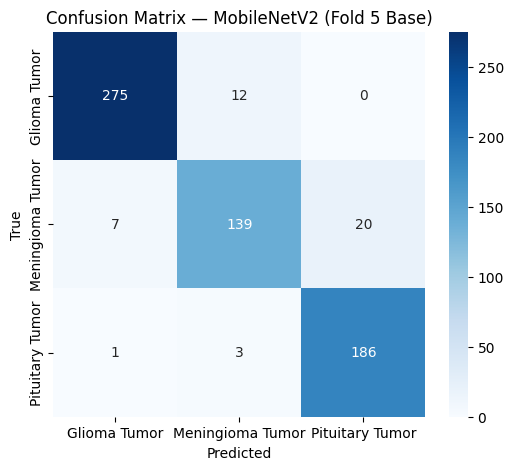

Fold 1 Accuracy: 98.15%
Fold 2 Accuracy: 95.29%
Fold 3 Accuracy: 96.33%
Fold 4 Accuracy: 96.97%
Fold 5 Accuracy: 93.31%
AVG accuracy (base): 96.01%


In [15]:
acc_folds = []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} Base')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_folds.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

for i, acc in enumerate(acc_folds):
    print(f'Fold {i+1} Accuracy: {acc * 100:.2f}%')

print(f'AVG accuracy (base): {np.mean(acc_folds)*100:.2f}%')